# 벡터DB 검색 성능 비교
쿼리 이미지를 3가지 임베딩 모델(CLIP / DINOv2-L / SigLIP)로 임베딩하고,
원본 / 스케치 쿼리 각각에 대해 검색 결과를 나란히 비교한다.

| DB | 모델 |
|---|---|
| `chroma_db` | CLIP ViT-B/32 |
| `chroma_db_dinov2` | DINOv2-Large |
| `chroma_db_siglip` | SigLIP-SO400M |

In [18]:
import cv2
import clip
import torch
import numpy as np
import chromadb
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel, AutoProcessor

/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 경로 설정

In [19]:
BASE_DIR    = "/Users/nanahyun/Documents/GitHub/final_develop/design/data"
CHROMA_CLIP    = "/Users/nanahyun/Documents/GitHub/final_develop/design/chroma_db"
CHROMA_DINOV2  = "/Users/nanahyun/Documents/GitHub/final_develop/design/chroma_db_dinov2"
CHROMA_SIGLIP  = "/Users/nanahyun/Documents/GitHub/final_develop/design/chroma_db_siglip"
N_RESULTS   = 10

QUERY_IMAGE_PATH = '/Users/nanahyun/Documents/GitHub/final_develop/design/data/images/1981-2011/3020110019307-09-01-2_12.jpg'

### CLIP / DINOv2-L / SigLIP  모델 로드

- CLIP: 이미지와 텍스트를 같은 벡터 공간에 매핑하도록 학습. 수억 쌍의 (이미지, 텍스트) 데이터로 대조 학습(contrastive learning)을 수행해서, 같은 의미의 이미지-텍스트 쌍은 가깝게, 다른 쌍은 멀게 배치.
    - 이미지+텍스트 하이브리드 검색 가능
    - zero-shot 일반화 능력 우수
    - 텍스트 alignment를 위해 학습됐기 때문에 순수 시각적 세부 구조(형태 디테일) 포착력이 다소 약함

- DINOv2-L: 텍스트 없이 이미지만으로 self-supervised 학습. 같은 이미지의 다른 crop/augmentation끼리 일치하도록 학습하여, 텍스트 없이도 시각적 구조를 깊이 이해하는 표현 학습. 
    - 텍스트에 끌려다니지 않아서 순수 형태/구조 유사도 포착 능력이 가장 강함
    - 세밀한 시각적 특징(윤곽선, 비율, 구조) 표현에 유리

- SigLIP: CLIP과 유사한 이미지-텍스트 대조 학습이지만, softmax 대신 sigmoid loss 사용. 배치 내 모든 쌍을 독립적으로 이진 분류(매칭/비매칭)처럼 학습하기 때문에, 배치 크기 의존성이 낮고 학습이 안정적.


=> Gemini JSON 텍스트 피처와 결합하는 하이브리드 구조를 유지한다면 CLIP/SigLIP 계열. DINOv2는 이미지 유사도 단독 레이어로만 활용하거나 앙상블 구성 시 고려할 수 있음.


In [ ]:
# 사전 학습된 CLIP, SigLIP, DINOv2 모델을 로드한다. 
# 이미 학습된 모델을 임베딩 목적으로 사용한다. 특징 추출기(feature extractor)로만 활용하는 구조다. 

device = "cuda" if torch.cuda.is_available() else "cpu"

# CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
print(f"CLIP 로드 완료 (Device: {device})")

# DINOv2-Large
dinov2_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-large")
dinov2_model     = AutoModel.from_pretrained("facebook/dinov2-large").to(device)
dinov2_model.eval()
print("DINOv2-Large 로드 완료")

# SigLIP-SO400M
siglip_processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")
siglip_model     = AutoModel.from_pretrained("google/siglip-so400m-patch14-384").to(device)
siglip_model.eval()
print("SigLIP-SO400M 로드 완료")

CLIP 로드 완료 (Device: cpu)


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 9022.00it/s]


DINOv2-Large 로드 완료


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 7140.45it/s]

SigLIP-SO400M 로드 완료


### 3개 ChromaDB 연결, 6개 컬렉션

In [21]:
def get_collections(chroma_dir):
    client = chromadb.PersistentClient(path=chroma_dir)
    return (
        client.get_collection("design_original"),
        client.get_collection("design_sketch"),
    )

clip_orig,   clip_sketch   = get_collections(CHROMA_CLIP)
dino_orig,   dino_sketch   = get_collections(CHROMA_DINOV2)
siglip_orig, siglip_sketch = get_collections(CHROMA_SIGLIP)

for name, col in [
    ("CLIP    original", clip_orig),   ("CLIP    sketch", clip_sketch),
    ("DINOv2  original", dino_orig),   ("DINOv2  sketch", dino_sketch),
    ("SigLIP  original", siglip_orig), ("SigLIP  sketch", siglip_sketch),
]:
    print(f"{name}: {col.count()}개")

CLIP    original: 1208개
CLIP    sketch: 1208개
DINOv2  original: 1208개
DINOv2  sketch: 1208개
SigLIP  original: 1208개
SigLIP  sketch: 1208개


In [22]:
def to_sketch(pil_image):
    img_array = np.array(pil_image.convert('L'))
    blurred   = cv2.GaussianBlur(img_array, (5, 5), 0)
    edges     = cv2.Canny(blurred, 30, 100)
    edges     = cv2.bitwise_not(edges)
    return Image.fromarray(edges).convert('RGB')

def embed_clip(pil_image):
    tensor = clip_preprocess(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        vec = clip_model.encode_image(tensor).cpu().numpy()
    return vec[0].tolist()

def embed_dinov2(pil_image):
    inputs = dinov2_processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dinov2_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0].tolist()

def embed_siglip(pil_image):
    inputs = siglip_processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        output = siglip_model.get_image_features(**inputs)
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        vec = output.pooler_output
    elif hasattr(output, 'last_hidden_state'):
        vec = output.last_hidden_state[:, 0, :]
    else:
        vec = output
    return vec.cpu().numpy()[0].tolist()

def load_image_from_url(url):
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert('RGB')
    except Exception:
        return None

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/1023423172.py:8: UserWarning: Glyph 53244 (\N{HANGUL SYLLABLE KWEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/1023423172.py:8: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/1023423172.py:8: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/1023423172.py:8: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/1023423172.py:8: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_

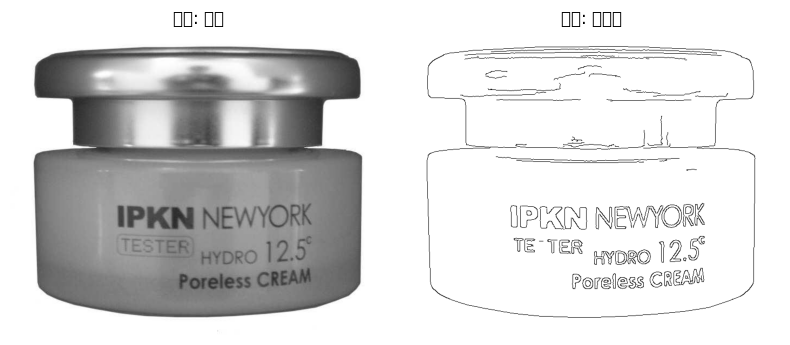

In [23]:
# 쿼리 원본 이미지와 스케치 이미지 생성
query_image  = Image.open(QUERY_IMAGE_PATH).convert('RGB')
sketch_image = to_sketch(query_image)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(query_image);  axes[0].set_title("쿼리: 원본");  axes[0].axis('off')
axes[1].imshow(sketch_image); axes[1].set_title("쿼리: 스케치"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [24]:
#	6가지 쿼리 한 번에 실행
vec_clip_orig   = embed_clip(query_image) #원본 이미지 임베딩 by CLIP
vec_clip_sk     = embed_clip(sketch_image) #스케치 이미지 임베딩 by CLIP
vec_dino_orig   = embed_dinov2(query_image) #원본 이미지 임베딩 by DINOv2
vec_dino_sk     = embed_dinov2(sketch_image) #스케치 이미지 임베딩 by DINOv2
vec_siglip_orig = embed_siglip(query_image) #원본 이미지 임베딩 by SigLIP
vec_siglip_sk   = embed_siglip(sketch_image) #스케치 이미지 임베딩 by SigLIP

results = {
    "CLIP / 원본":      clip_orig.query(query_embeddings=[vec_clip_orig],   n_results=N_RESULTS),
    "CLIP / 스케치":    clip_sketch.query(query_embeddings=[vec_clip_sk],    n_results=N_RESULTS),
    "DINOv2 / 원본":    dino_orig.query(query_embeddings=[vec_dino_orig],   n_results=N_RESULTS),
    "DINOv2 / 스케치":  dino_sketch.query(query_embeddings=[vec_dino_sk],   n_results=N_RESULTS),
    "SigLIP / 원본":    siglip_orig.query(query_embeddings=[vec_siglip_orig], n_results=N_RESULTS),
    "SigLIP / 스케치":  siglip_sketch.query(query_embeddings=[vec_siglip_sk], n_results=N_RESULTS),
}

for key, res in results.items():
    print(f"{key}: {len(res['ids'][0])}개 검색 완료")

CLIP / 원본: 10개 검색 완료
CLIP / 스케치: 10개 검색 완료
DINOv2 / 원본: 10개 검색 완료
DINOv2 / 스케치: 10개 검색 완료
SigLIP / 원본: 10개 검색 완료
SigLIP / 스케치: 10개 검색 완료


In [25]:
def show_results(res, title):
    ids       = res['ids'][0]
    distances = res['distances'][0]
    metadatas = res['metadatas'][0]

    cols = 5
    rows = (len(ids) + cols - 1) // cols
    fig  = plt.figure(figsize=(cols * 4, rows * 4))
    fig.suptitle(title, fontsize=15, fontweight='bold')

    for i, (id_, dist, meta) in enumerate(zip(ids, distances, metadatas)):
        ax = fig.add_subplot(rows, cols, i + 1)
        img = load_image_from_url(meta.get('imagePath', ''))
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, '이미지\n없음', ha='center', va='center', transform=ax.transAxes)
        label = (
            f"#{i+1}  유사도: {1-dist:.3f}\n"
            f"{meta.get('articleName', '')} ({meta.get('LCCode', '')})\n"
            f"{meta.get('admstStat', '')}  |  도면 {meta.get('imageNumber', '')}"
        )
        ax.set_title(label, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## CLIP 결과

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykerne

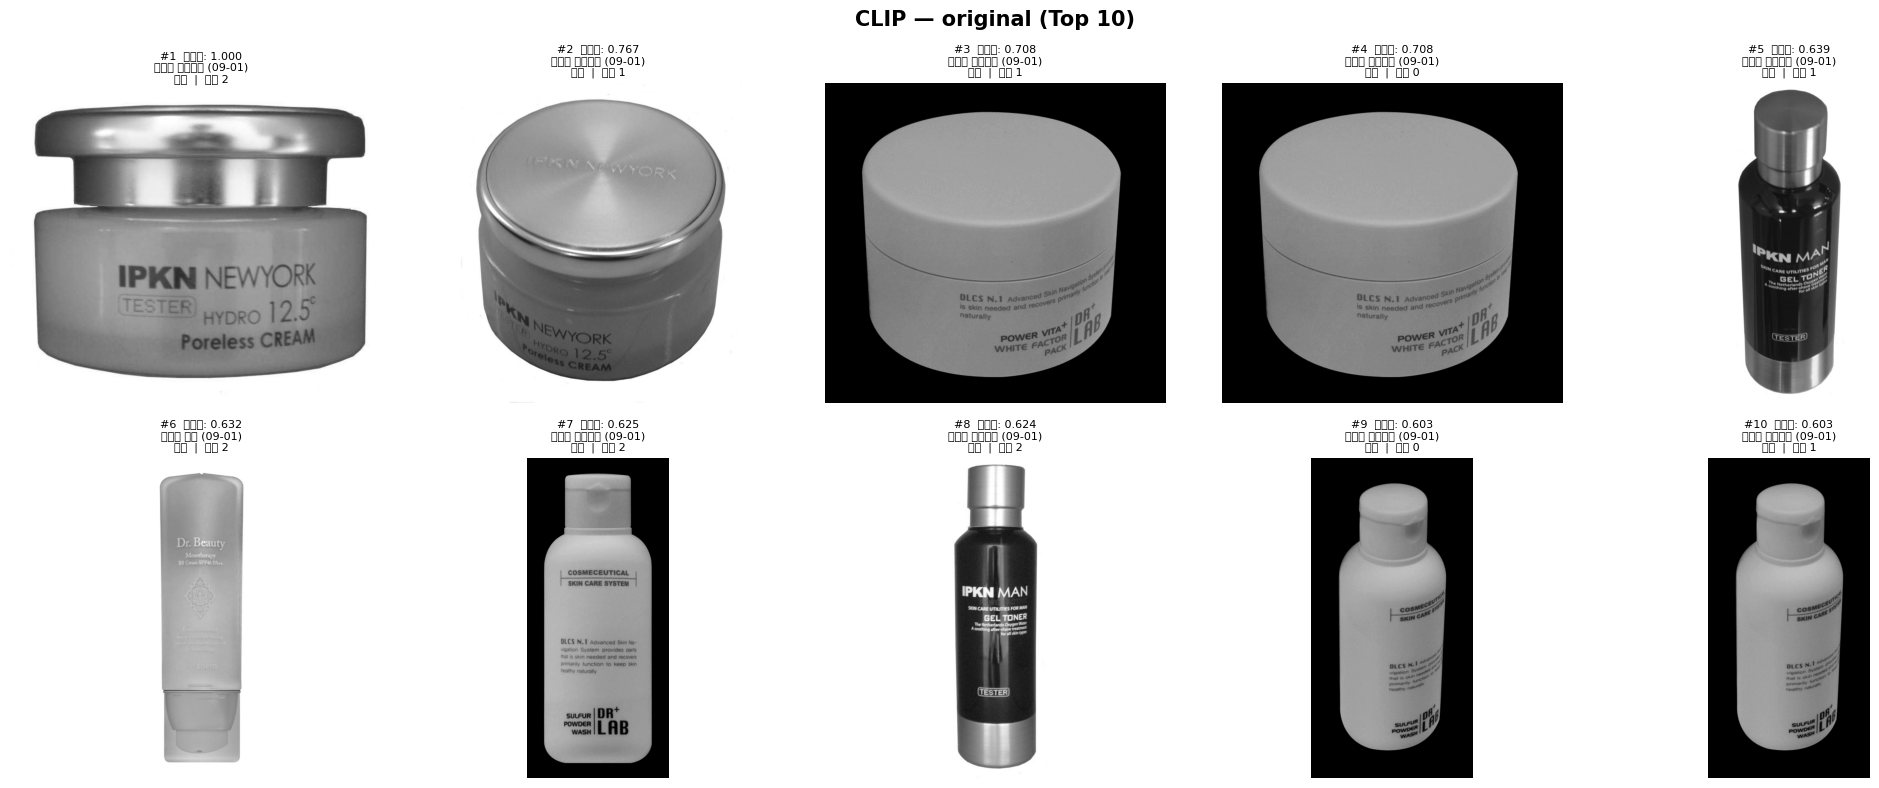

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


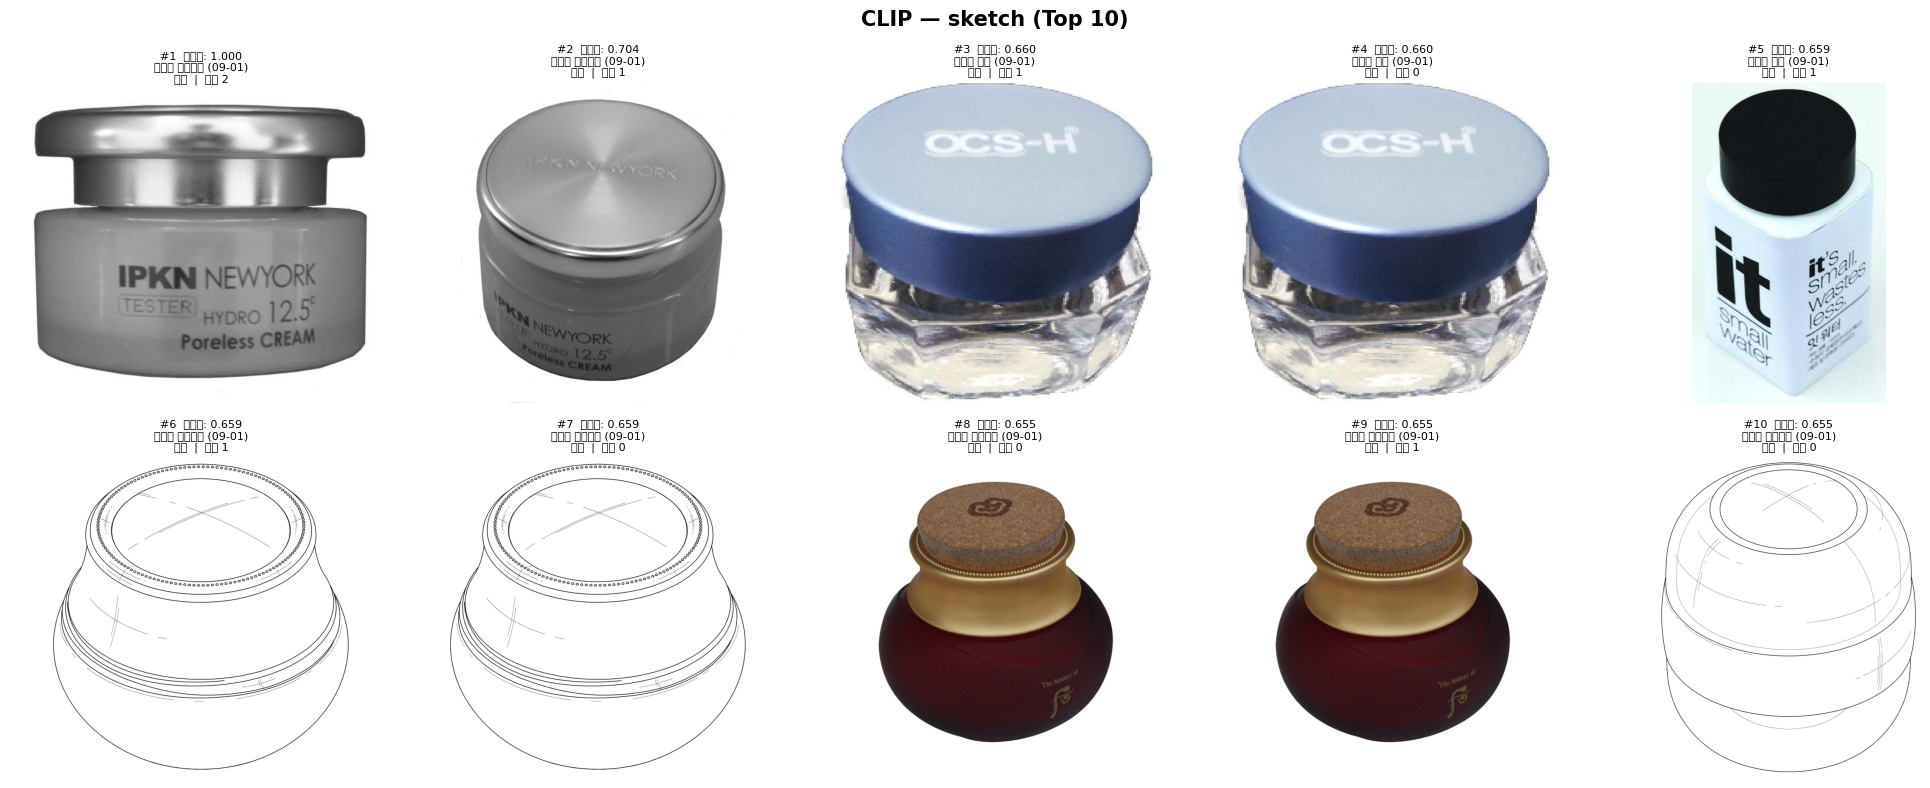

In [27]:
show_results(results["CLIP / 원본"],   f"CLIP — original (Top {N_RESULTS})")
show_results(results["CLIP / 스케치"], f"CLIP — sketch (Top {N_RESULTS})")

## DINOv2 결과

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykerne

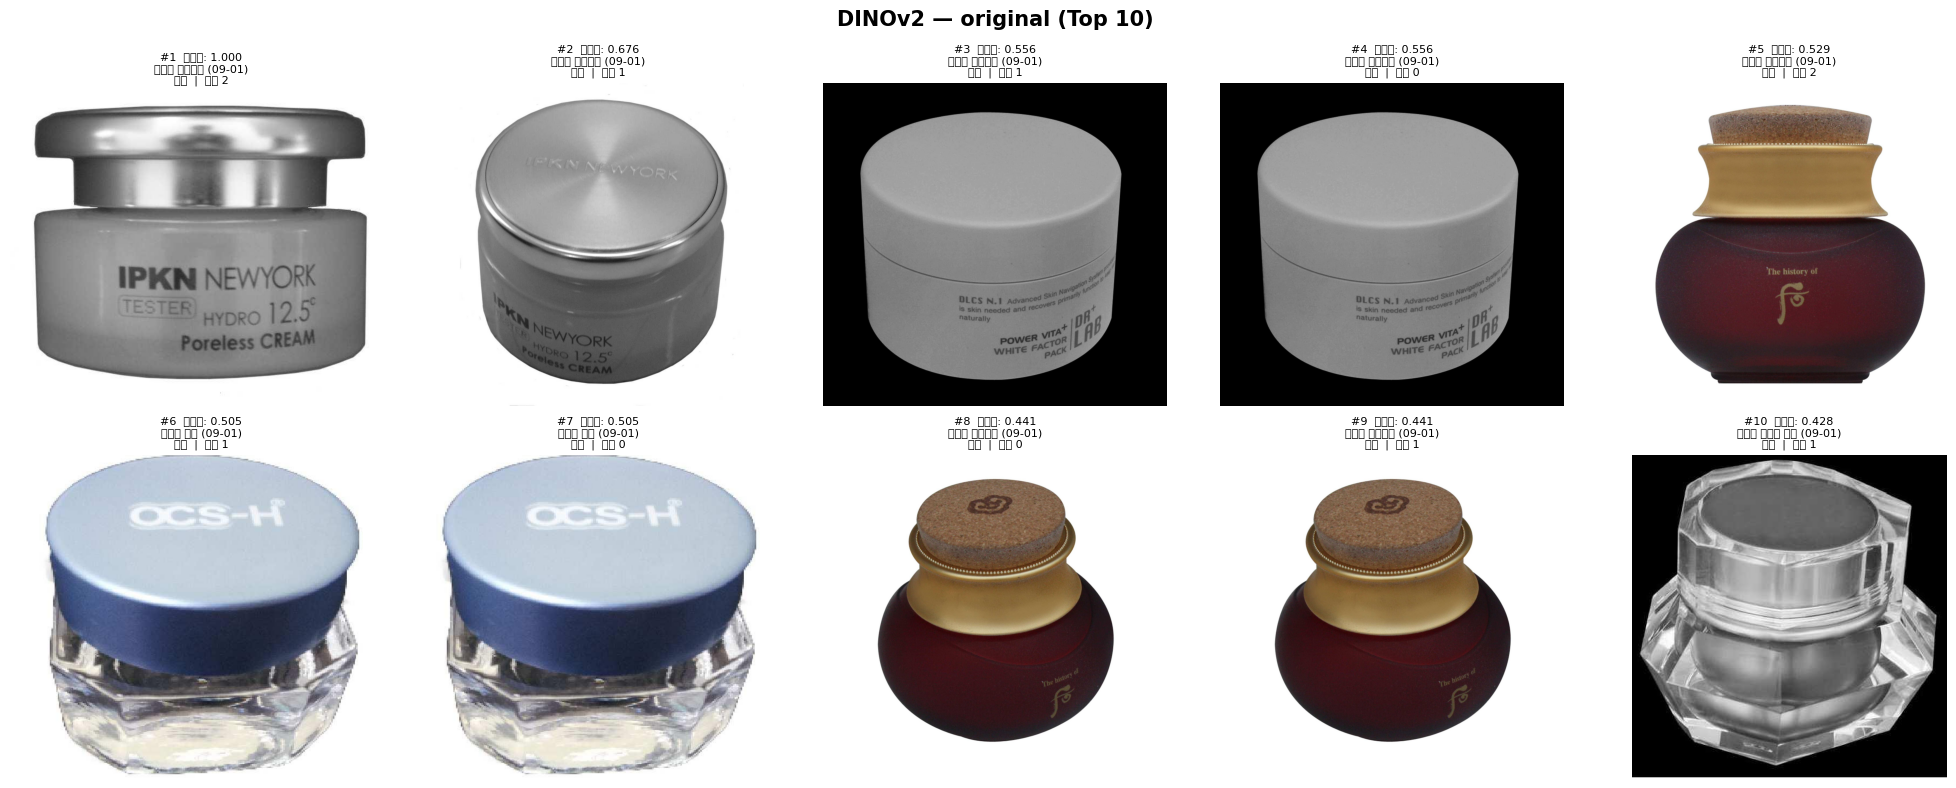

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 47736 (\N{HANGUL SYLLABLE MYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

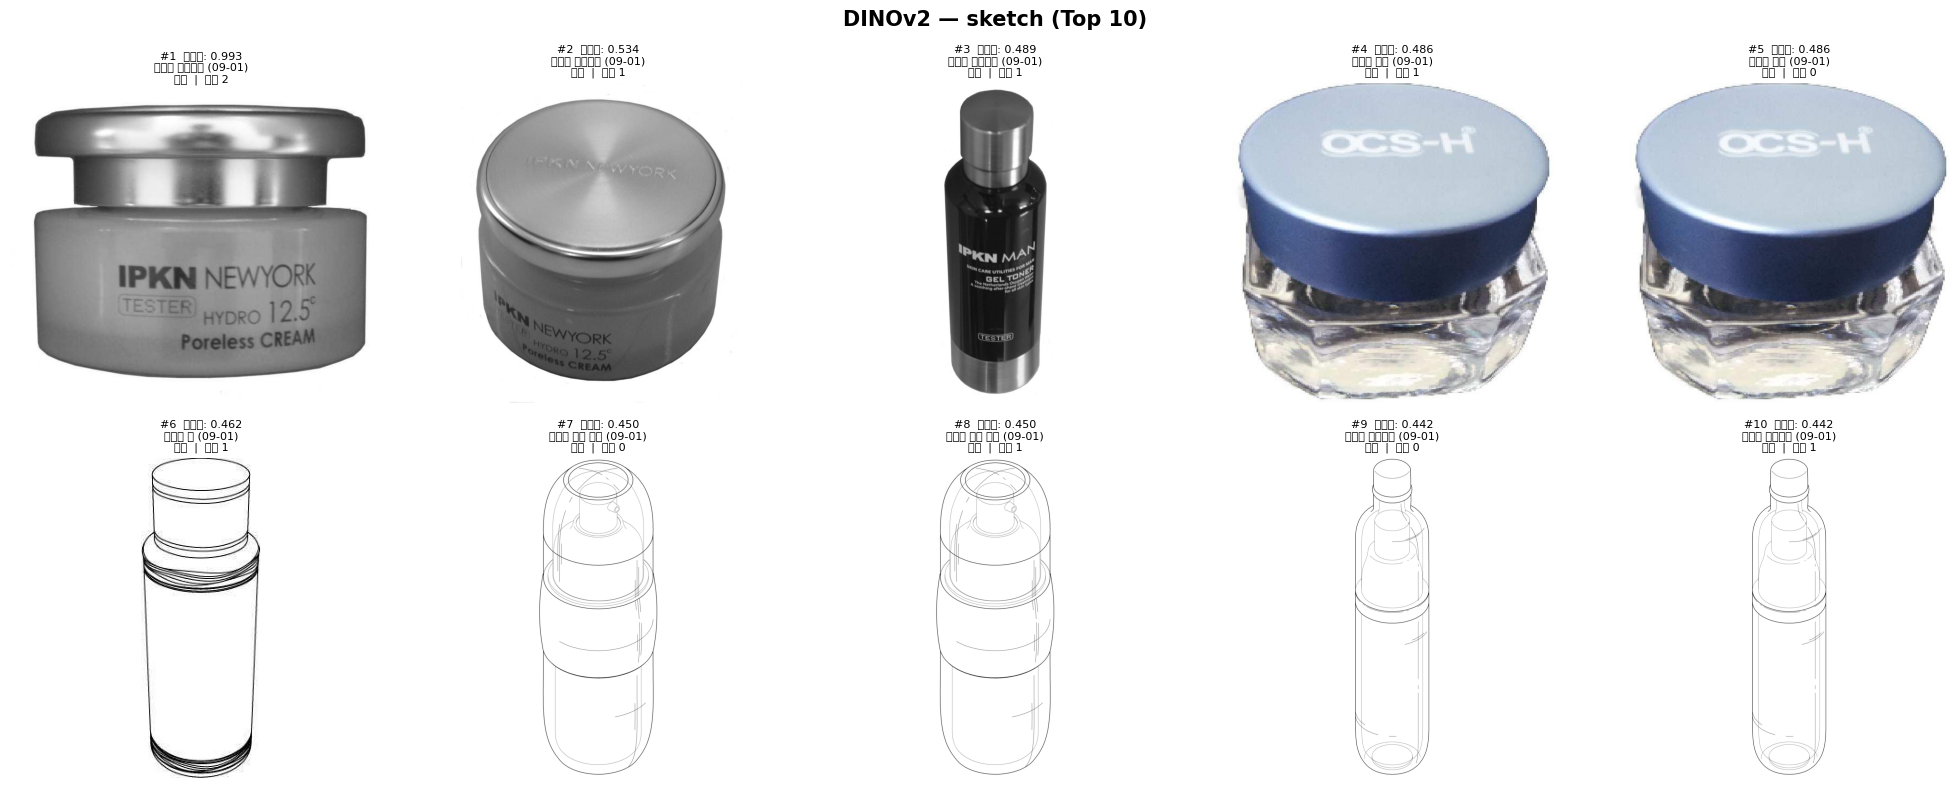

In [28]:
show_results(results["DINOv2 / 원본"], f"DINOv2 — original (Top {N_RESULTS})")
show_results(results["DINOv2 / 스케치"], f"DINOv2 — sketch (Top {N_RESULTS})")

## SigLIP 결과

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykerne

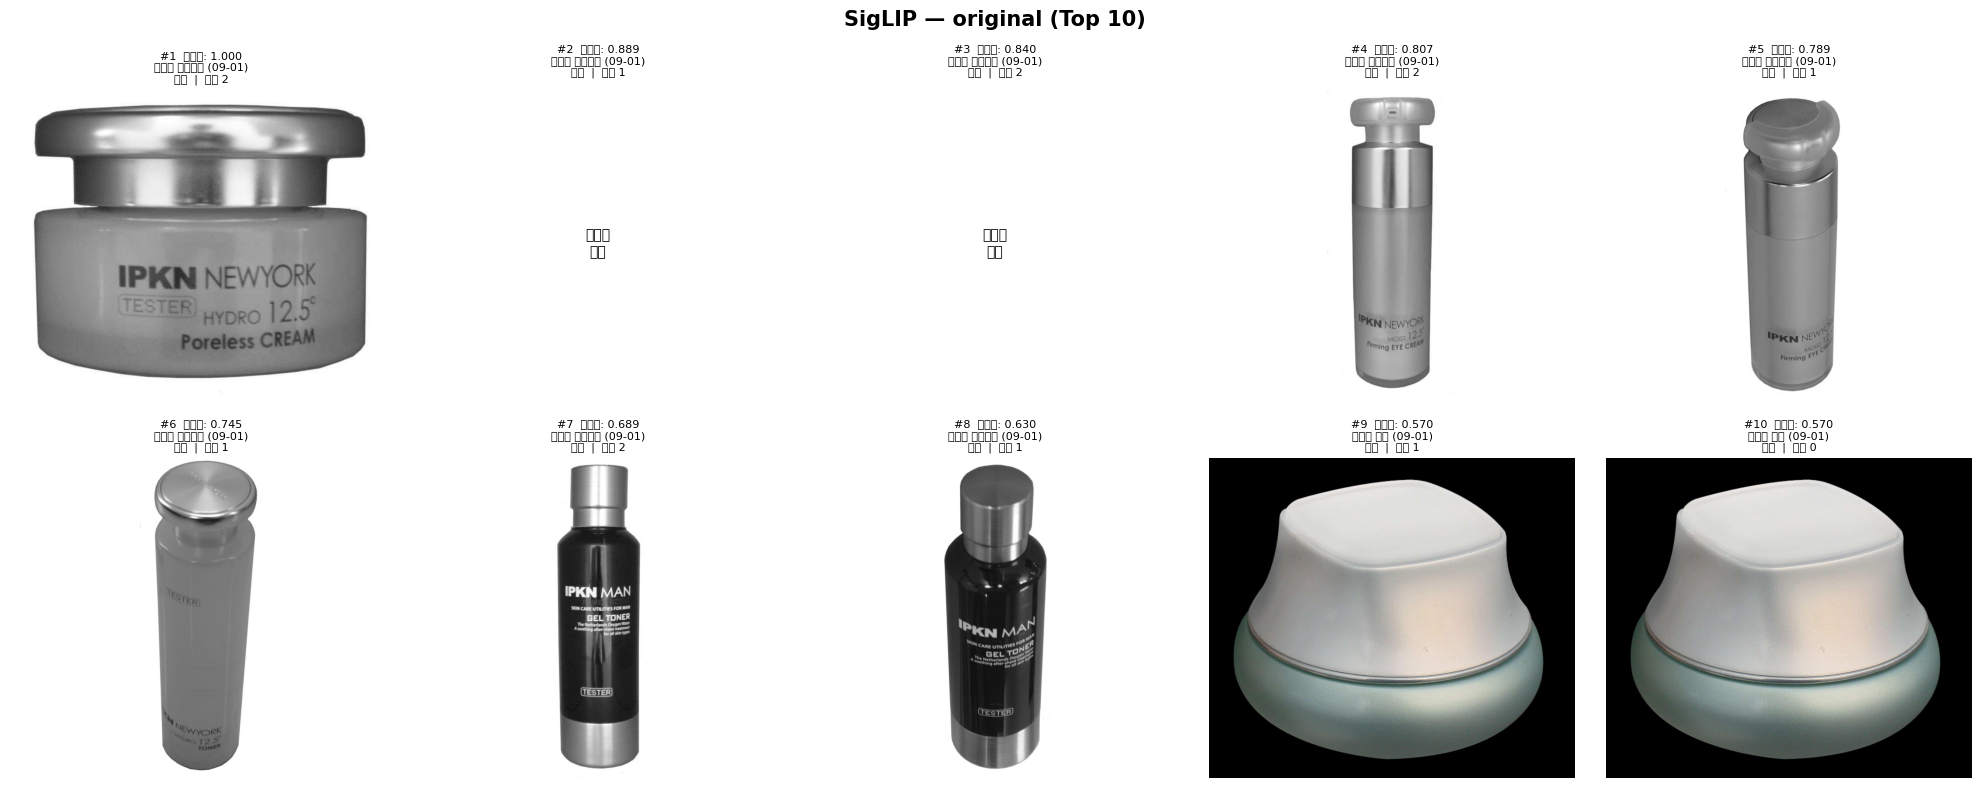

/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 46748 (\N{HANGUL SYLLABLE DDU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 44753 (\N{HANGUL SYLLABLE GGEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fp/pf5d987j21l49z14fhfcysmw0000gn/T/ipykernel_51719/2306561857.py:26: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/miniconda3/envs/final_develop/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46748 (\N{HANGUL SYLLABLE DDU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/en

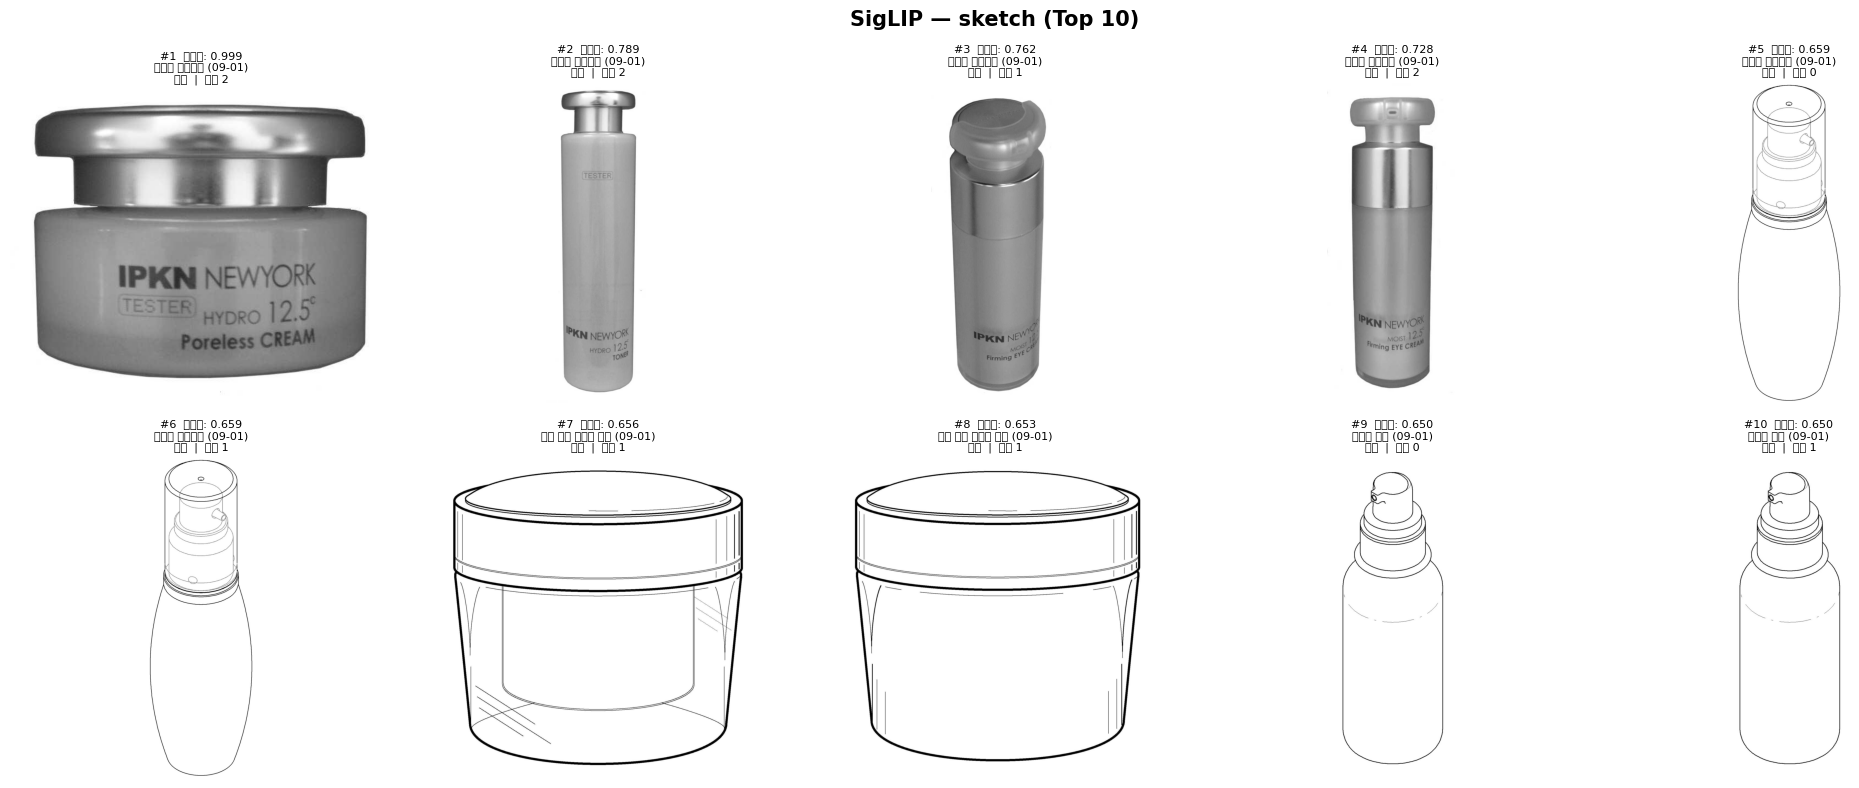

In [29]:
show_results(results["SigLIP / 원본"],   f"SigLIP — original (Top {N_RESULTS})")
show_results(results["SigLIP / 스케치"], f"SigLIP — sketch (Top {N_RESULTS})")

---
## Ground Truth 기반 성능 평가
- CSV: `huristic_testdata_filtered.csv`
- 쿼리 이미지로 각 6개 DB 검색 → 정답(relevant_image)이 몇 번째에 나오는지 측정
- Hit@5 / 10 / 20 / 30 / 50 / 100 및 평균 순위 출력

In [ ]:
import csv

CSV_PATH  = "/Users/nanahyun/Documents/GitHub/final_develop/design/data/test_data/huristic/huristic_testdata_filtered.csv"
IMAGE_DIR_EVAL = f"{BASE_DIR}/images/통합"
HIT_KS = [5, 10, 20, 30, 50, 100]
EVAL_N = 100  # 최대 검색 개수

with open(CSV_PATH, encoding="utf-8-sig") as f:
    eval_rows = list(csv.DictReader(f))

print(f"평가 데이터: {len(eval_rows)}쌍")

In [ ]:
def parse_filename(fname):
    """파일명 → (applicationNumber, imageNumber) 추출
    형식: {app_num}-{lc1}-{lc2}-{drawing_num}_{idx}.jpg
    예:   3020130049388-09-01-0_12.jpg
    """
    name = os.path.splitext(fname)[0]          # 확장자 제거
    base, _ = name.rsplit("_", 1)              # 마지막 _ 기준 분리
    parts = base.split("-")                    # - 기준 분리
    app_num  = parts[0]                        # 13자리 출원번호
    draw_num = parts[-1]                       # 마지막이 도면번호
    return app_num, draw_num

def find_rank(metadatas, app_num, draw_num):
    """정답이 몇 번째 결과인지 반환 (없으면 None)"""
    for i, m in enumerate(metadatas):
        if (str(m.get("applicationNumber","")) == app_num and
            str(m.get("imageNumber",""))      == draw_num):
            return i + 1
    return None

In [ ]:
collections_eval = {
    "CLIP / 원본":     (clip_orig,    lambda img: embed_clip(img)),
    "CLIP / 스케치":   (clip_sketch,  lambda img: embed_clip(to_sketch(img))),
    "DINOv2 / 원본":   (dino_orig,    lambda img: embed_dinov2(img)),
    "DINOv2 / 스케치": (dino_sketch,  lambda img: embed_dinov2(to_sketch(img))),
    "SigLIP / 원본":   (siglip_orig,  lambda img: embed_siglip(img)),
    "SigLIP / 스케치": (siglip_sketch,lambda img: embed_siglip(to_sketch(img))),
}

eval_stats = {name: {"ranks": []} for name in collections_eval}

for i, row in enumerate(eval_rows):
    q_path = os.path.join(IMAGE_DIR_EVAL, row["query_image"])
    if not os.path.exists(q_path):
        print(f"[{i}] 쿼리 이미지 없음: {row['query_image']}")
        for name in collections_eval:
            eval_stats[name]["ranks"].append(None)
        continue

    query_img = Image.open(q_path).convert("RGB")
    rel_app, rel_draw = parse_filename(row["relevant_image"])

    for name, (col, embed_fn) in collections_eval.items():
        vec = embed_fn(query_img)
        res = col.query(query_embeddings=[vec], n_results=EVAL_N)
        rank = find_rank(res["metadatas"][0], rel_app, rel_draw)
        eval_stats[name]["ranks"].append(rank)

    if (i + 1) % 5 == 0 or (i + 1) == len(eval_rows):
        print(f"진행: {i+1}/{len(eval_rows)}")

print("\n평가 완료!")

In [ ]:
total = len(eval_rows)

header = f"{"모델/DB":<20}" + "".join(f"  Hit@{k:<3}" for k in HIT_KS) + "  평균순위  중앙값순위  NotFound"
print("=" * len(header))
print(header)
print("=" * len(header))

for name, data in eval_stats.items():
    ranks = data["ranks"]
    valid = [r for r in ranks if r is not None]
    not_found = ranks.count(None)
    avg_rank    = sum(valid) / len(valid) if valid else float("inf")
    median_rank = sorted(valid)[len(valid) // 2] if valid else float("inf")

    row_str = f"{name:<20}"
    for k in HIT_KS:
        hit = sum(1 for r in ranks if r is not None and r <= k)
        row_str += f"  {hit/total*100:5.1f}%"
    row_str += f"  {avg_rank:7.1f}   {median_rank:6.0f}      {not_found}"
    print(row_str)

print("=" * len(header))
print(f"\n총 쿼리: {total}개")
print("\n--- 각 DB별 정답 순위 분포 ---")
for name, data in eval_stats.items():
    ranks = data["ranks"]
    valid = [r for r in ranks if r is not None]
    top1  = sum(1 for r in valid if r == 1)
    top3  = sum(1 for r in valid if r <= 3)
    print(f"{name:<20}  1위: {top1}  3위이내: {top3}  전체검색됨: {len(valid)}/{total}")